## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

2024-09-02 19:43:10.399897: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-02 19:43:10.399943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-02 19:43:10.400647: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-02 19:43:10.405044: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-02 19:43:10.980811: W tensorflow/compiler/tf2

In [2]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'

RX_NODES_V2 = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]
DATA_CONFIG_V2 = {
    'dataset_name': DatasetAPI.DATASET_V2,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 2,
    'samples_count': 400
}

AUG_CONFIG = {
    'multiplier': 5,
    't_rms_bounds': matlab.double([1, 2]),
    'd_f_bounds': matlab.double([0, 10]),
    'k_factor_bounds': matlab.double([0, 10]),
    'awgn': matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size': 32,
    # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
    'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
    #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
    # 'loss_type': 'n_loss', 'loss_num_neg': 2,
    'npair_type': 'samedev',
    # 'npair_type': 'diffdev',
    'alpha': 1.0, # used only for triple & quadruple loss
    'patience': 10,
    'fp_len': 512,
    'row': 50
}

In [3]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)

In [4]:
fp_api.load_models()

2024-09-02 19:43:17.816320: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 77558 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-09-02 19:43:17.817767: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 76889 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-09-02 19:43:17.819058: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79060 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


{'node1-1': <keras.src.engine.functional.Functional at 0x7f0884eaf4f0>,
 'node1-20': <keras.src.engine.functional.Functional at 0x7f087c041090>,
 'node20-1': <keras.src.engine.functional.Functional at 0x7f087c0bbb50>,
 'node19-19': <keras.src.engine.functional.Functional at 0x7f08181197b0>}

/home/smazokha2016/miniconda3/envs/shen/lib/python3.10/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


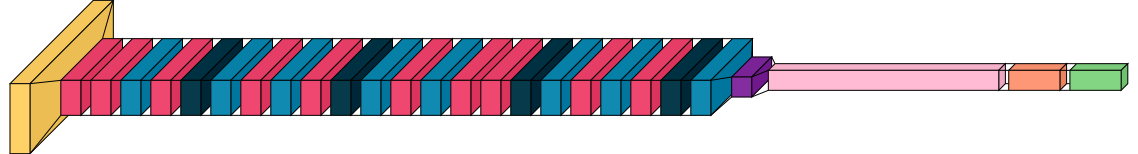

<Figure size 6000x1800 with 0 Axes>

In [24]:
import visualkeras
import matplotlib.pyplot as plt
from PIL import ImageFont

font = ImageFont.truetype("courbd.ttf", 20)  
plt.figure(figsize=(20, 6), dpi=300)
visualkeras.layered_view(fp_api.models[DatasetAPI.RX_1], 
                         legend=False, 
                         scale_xy=5,
                         show_dimension=False, 
                         shade_step=10,
                         font_color='black',
                         font=font,
                         to_file='/home/smazokha2016/Desktop/model_visualization.png')
# fp_api.models[DatasetAPI.RX_1].summary()

### 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

Load the training dataset
Processing offset 0
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.33%
Processing offset 1
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.0%
Processing offset 2
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.22%
Processing offset 3
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 97.11%
Processing offset 4
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 95.89%


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Accuracy: 16.0%


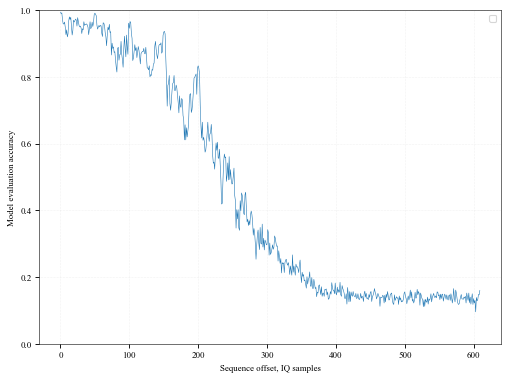

Load the training dataset
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 19ms/step - loss: 1.4963 - val_loss: 1.5270 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 20ms/step - loss: 1.4684 - val_loss: 1.4524 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 1.4802 - val_loss: 1.5187 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.4700 - val_loss: 1.4139 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.4574 - val_loss: 1.4835 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 4s 21ms/step - loss: 1.4315 - val_loss: 1.4140 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.3793 - val_loss: 1.3769 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.3010 - val_loss: 1.2251 - lr: 0.0010
Epoch 9/1000
163/163 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


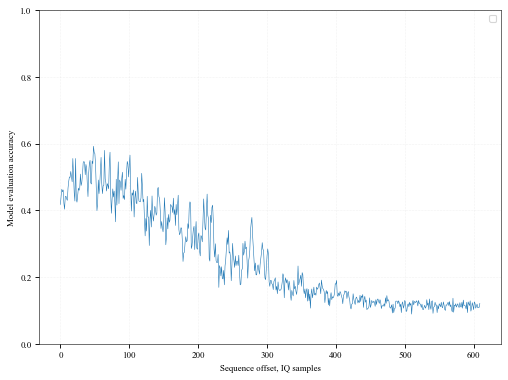

Done


In [79]:
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=0, offset_range=np.arange(0, 610, 1), use_pretrained=True, 
                                  fig_name="Preamble offset evaluation: preamble-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig1.eps'))
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=400, offset_range=np.arange(0, 610, 1), use_pretrained=False, 
                                  fig_name="Preamble offset evaluation: random data-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig2.eps'))

print('Done')

### 2. Triplet vs. quadruplet training loss function

Every bit matters. Let's try adopting a quadruplet loss function and explore model performance on an identical dataset & settings.

Note: currently, the test is being performed under open-set conditions. You can override this by defining identical device ID sets in this function, and run closed-set test.

Load the training dataset
Evaluating for triplet_loss
Applying triplet_loss
Epoch 1/1000
163/163 [==============================] - 5s 18ms/step - loss: 0.1503 - val_loss: 0.0301 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 2s 15ms/step - loss: 0.0231 - val_loss: 0.0182 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 17ms/step - loss: 0.0103 - val_loss: 0.0037 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 16ms/step - loss: 0.0051 - val_loss: 0.0033 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0025 - val_loss: 8.1786e-04 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 2s 15ms/step - loss: 0.0023 - val_loss: 8.5101e-04 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 17ms/step - loss: 0.0014 - val_loss: 0.0013 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 2s 14ms/step - loss: 8.6288e-04 - val_loss: 0.00

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


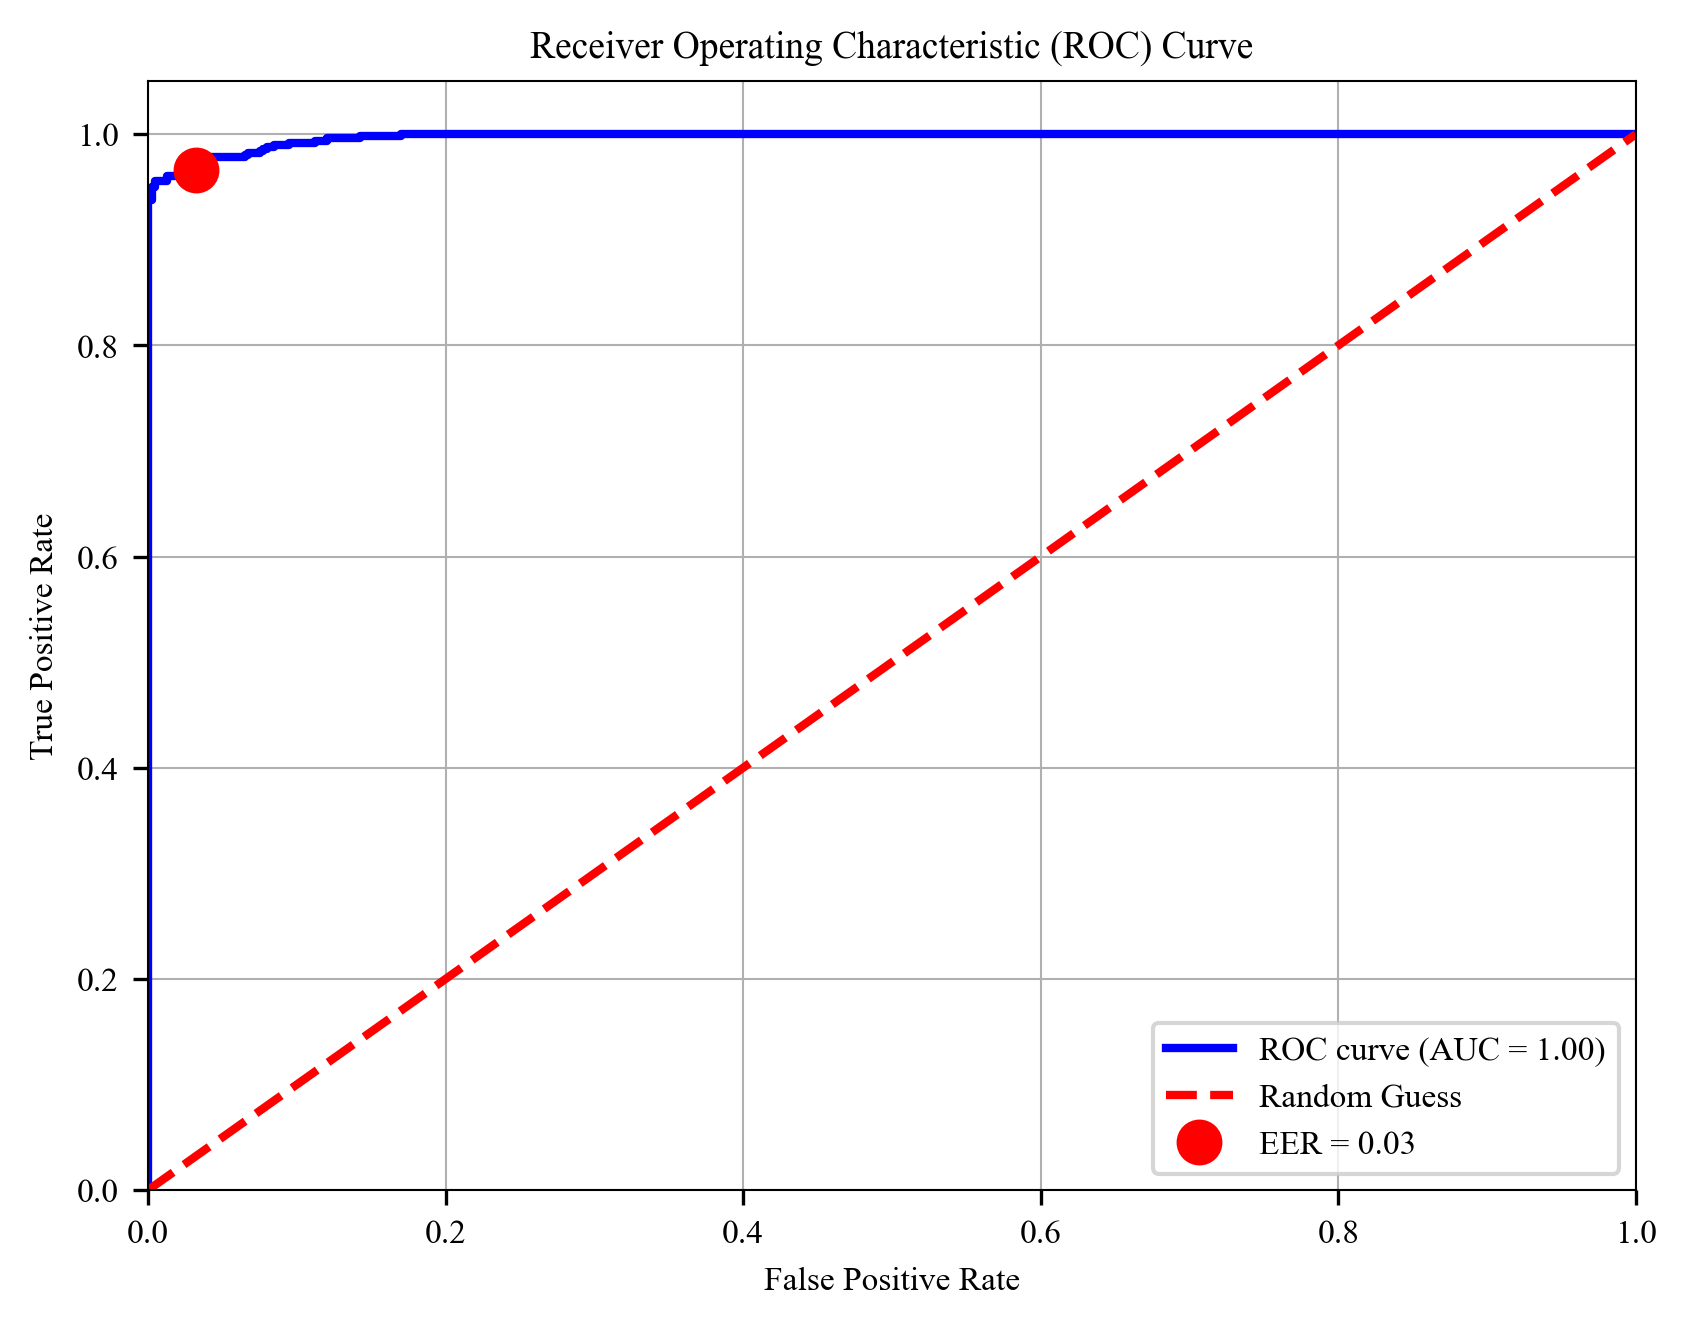

Evaluating for quadruplet_loss
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 19ms/step - loss: 0.4276 - val_loss: 0.1909 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 19ms/step - loss: 0.1456 - val_loss: 0.0975 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0959 - val_loss: 0.0811 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0637 - val_loss: 0.0662 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 4s 21ms/step - loss: 0.0496 - val_loss: 0.0429 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0392 - val_loss: 0.0294 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0241 - val_loss: 0.0231 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0171 - val_loss: 0.0134 - lr: 0.0010
Epoch 9/1000
163

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


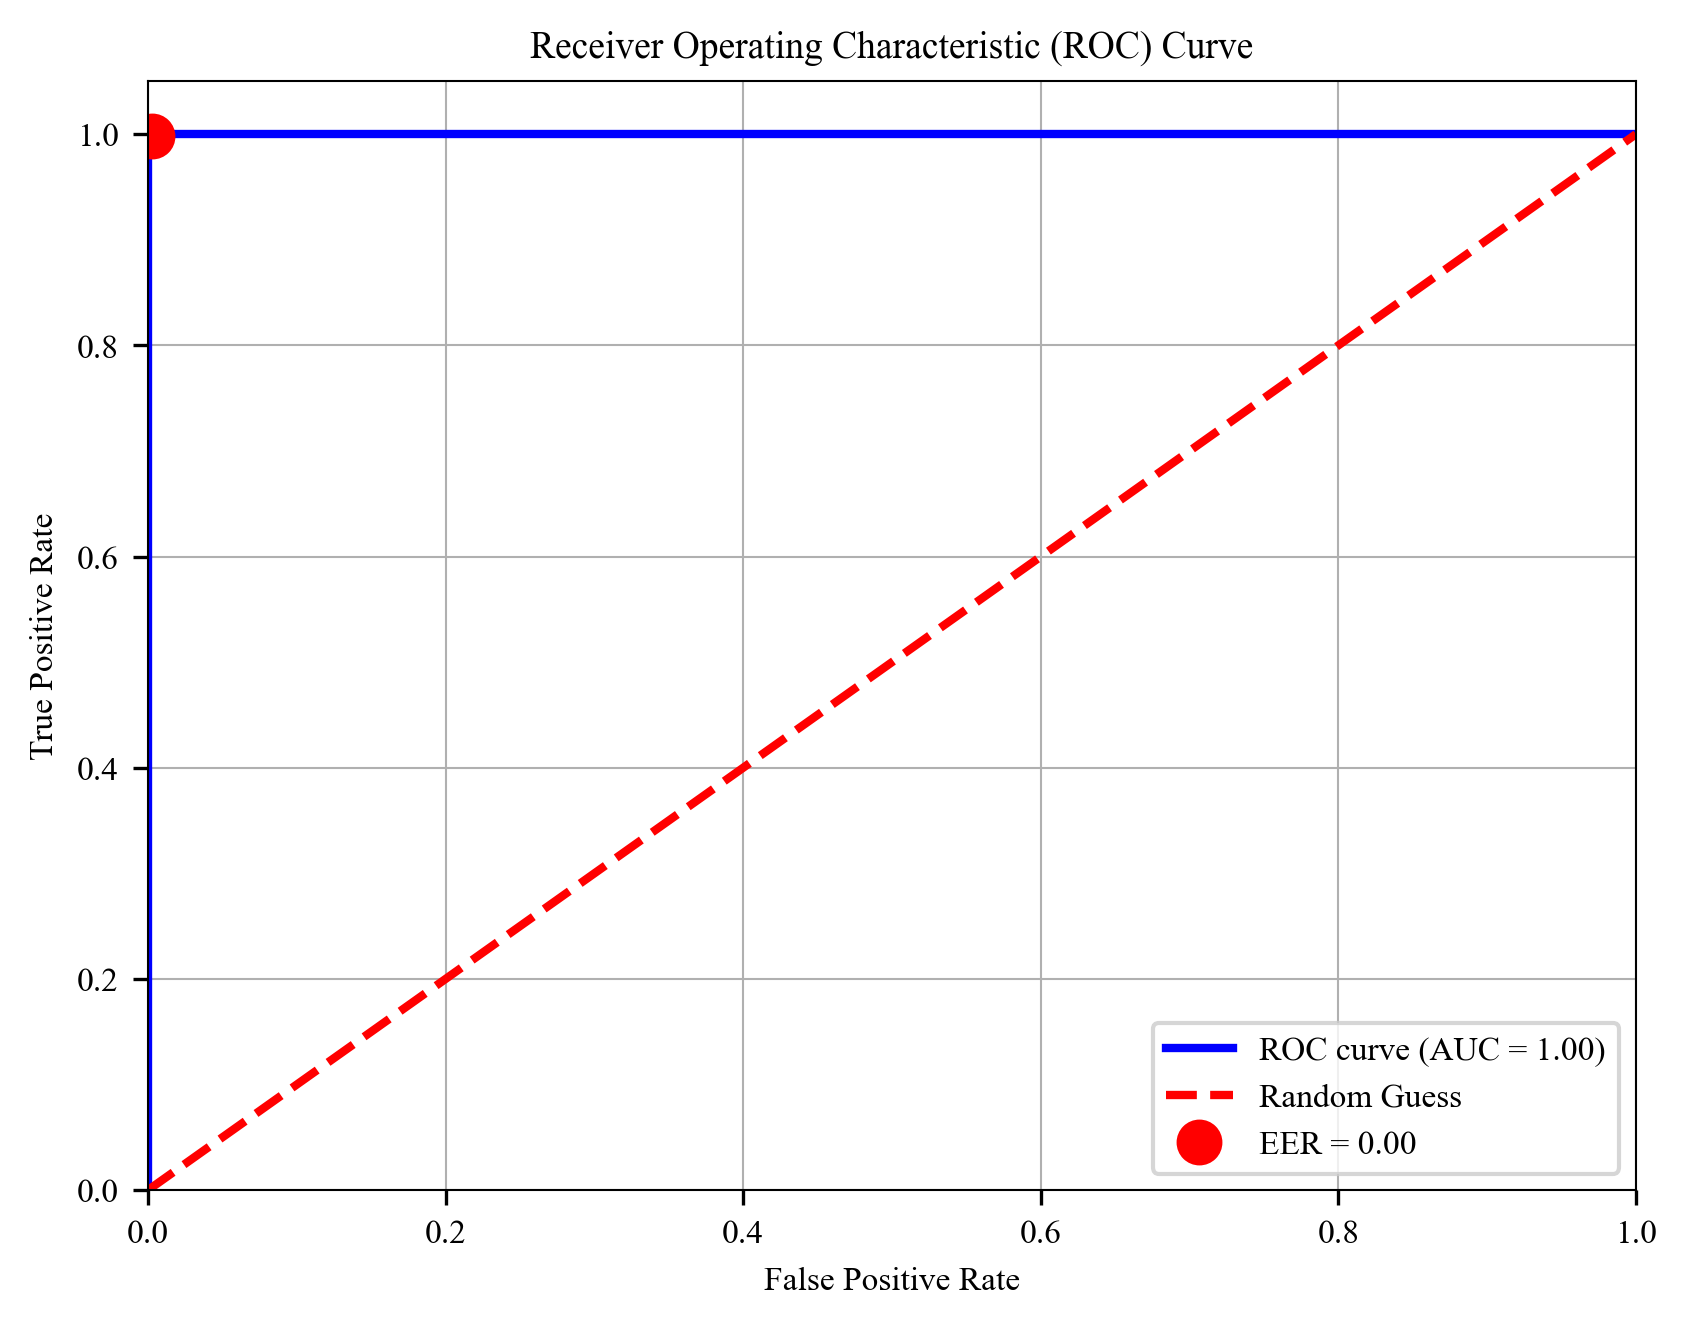

In [22]:
eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, fig_path = ROOT_DIRECTORY)

### 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
3/3 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
3/3 [==============================] - 0s 3ms/step
Generating eval finerprints for node20-1...
3/3 [==============================] - 0s 3ms/step
Generating eval finerprints for node19-19...
3/3 [==============================] - 0s 2ms/step


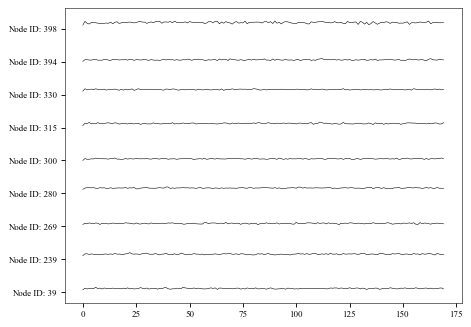

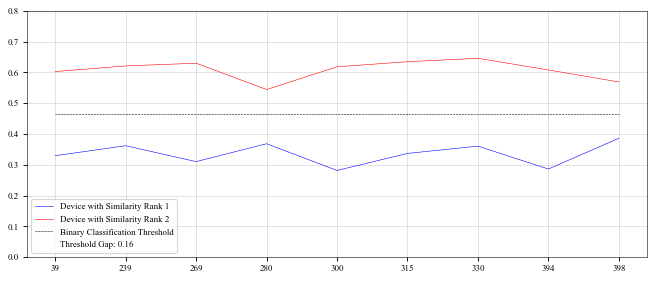

In [80]:
# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

node_ids_epoch_override=[39, 239, 269, 280, 300, 315, 330, 394, 398]

fp_distances = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2, 
    node_ids_epoch_override, 
    epochs_override=None, fig_path=ROOT_DIRECTORY, render_heatmaps=False, render_temp_stability=True, rank_dist_fig_file = False)

### 4. Multi-RX fingerprinting

The task here is slightly more interesting. While previously we evaluated the process of training the model, as well as whether the model can extract time-insensitive features -- now we can consider whether it's possible to improve the system performance by combining (aka fusing) fingerprints from multiple receivers that "hear" our signal simultaneously. 

This requires a slightly different process. Previous model tests could be performed while using a simple KNN-based evaluator. This step requires building out a custom evaluator, which is going to let us combine KNN distances with our custom weight factor -- RSSI (normalized between 0 and 1 on a -100 to 0 dB scale). 

Here's how this evaluation will work: 

1. We will build an evaluator which performs the evaluation process using a custom list of receivers. 
2. We will then run this evaluator for the following combinations:
    * RX 1
    * RX 2
    * RX 3
    * RX 4
    * RX 1, 2
    * RX 1, 2, 3
    * rX 1, 2, 3, 4
3. We will compare their performance on both closed-set and open-set scenarios, and produce the same accuracy metrics as before
4. Optionally, we will let the user render a rank 1-2 plot across all devices

In [25]:
from dataset_preparation import awgn

aug_on = False
apply_noise = False

epoch_idx_enroll = 0
epoch_idx_identify = 1

enroll_device_idx = [39, 239, 269, 280, 300]
identify_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398]

frame_count_enroll = frame_count_identify = 100

models = {}
data_epochs_1 = {}
labels_epochs_1 = {}
data_epochs_2 = {}
labels_epochs_2 = {}
rssis_epoch_2 = {}

for rx_id in RX_NODES_V2:
    print("Load the training dataset")
    dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG_V2['dataset_name'], rx_id, None)
    if aug_on: data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, AUG_CONFIG, shuffle=True)
    else: data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, DATA_CONFIG_V2['frame_count_train']))
    if apply_noise: data = awgn(data, np.arange(AUG_CONFIG['awgn'][0][0], AUG_CONFIG['awgn'][0][1]))
    data_train = data[:, 0:0+DATA_CONFIG_V2['samples_count']]

    # feature_extractor, _ = extractor_api.train(data_train, label, node_ids_train, MODEL_CONFIG, save_path=None)
    models[rx_id] = extractor_api.load(os.path.join(model_path, f"extractor_{rx_id}.keras"))

    # Load data (two epochs: one to enroll devices, another to identify devices)
    data_enroll, labels_enroll, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_enroll], shuffle=True)
    data_identify, labels_identify, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_identify], shuffle=True)

    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, rssi_enroll, dev_range=enroll_device_idx, pkt_range=np.arange(frame_count_enroll))
    data_identify, labels_identify, rssi_identify = dataset_api.filter_dataset(data_identify, labels_identify, rssi_identify, dev_range=identify_device_idx, pkt_range=np.arange(frame_count_identify))

    data_epochs_1[rx_id] = data_enroll[:, 0:DATA_CONFIG_V2['samples_count']]
    data_epochs_2[rx_id] = data_identify[:, 0:DATA_CONFIG_V2['samples_count']]

    labels_epochs_1[rx_id] = labels_enroll
    labels_epochs_2[rx_id] = labels_identify

    rssis_epoch_2[rx_id] = rssi_identify

Load the training dataset
Load the training dataset
Load the training dataset
Load the training dataset


['node1-1', 'node1-20', 'node20-1', 'node19-19']
Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1', 'node1-20', 'node20-1', 'node19-19']
29/29 [==============================] - 0s 2ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


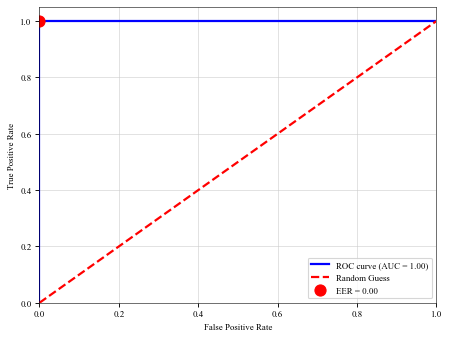

In [46]:
# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES_V2[0:1], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx1.eps'))

# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES_V2[0:2], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx12.eps'))

# eval_api.evaluate_open_set_knn_multirx(
#     models, RX_NODES_V2[0:3], 
#     data_epochs_1, labels_epochs_1, 
#     data_epochs_2, labels_epochs_2, rssis_epoch_2, 
#     MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx123.eps'))

eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES_V2[0:4], 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx1234.eps'))

Generating eval finerprints for node1-20...
3/3 [==============================] - 0s 3ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


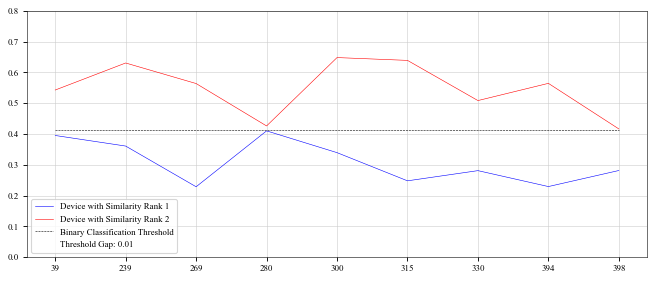

Generating eval finerprints for node1-1...
3/3 [==============================] - 0s 3ms/step
Generating eval finerprints for node1-20...
3/3 [==============================] - 0s 2ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


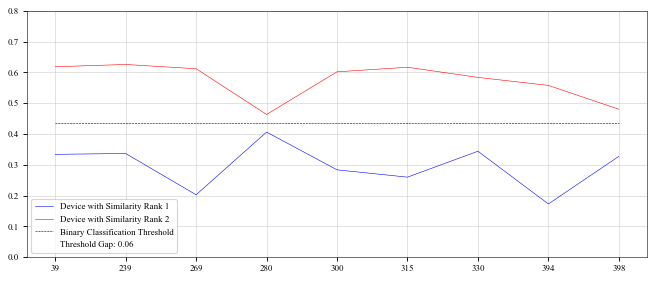

Generating eval finerprints for node1-1...
3/3 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
3/3 [==============================] - 0s 3ms/step
Generating eval finerprints for node20-1...
3/3 [==============================] - 0s 3ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


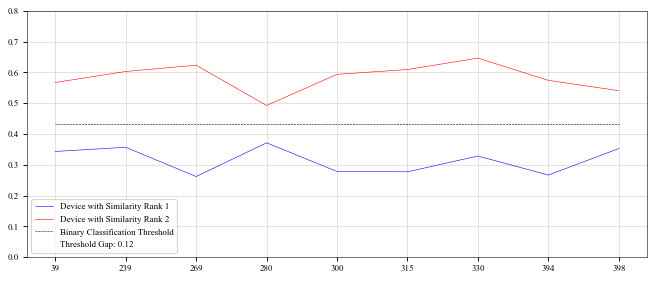

Generating eval finerprints for node1-1...
3/3 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
3/3 [==============================] - 0s 2ms/step
Generating eval finerprints for node20-1...
3/3 [==============================] - 0s 3ms/step
Generating eval finerprints for node19-19...
3/3 [==============================] - 0s 2ms/step


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


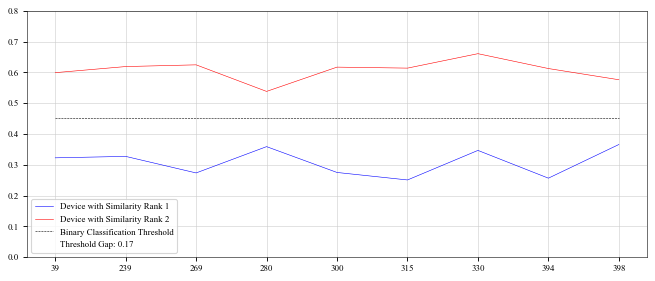

In [75]:
epochs = [
    'epoch_2024-07-20_01-15-26',
    'epoch_2024-07-20_01-25-24'
]

fp_distances_1 = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[1:2], 
    identify_device_idx, 
    epochs_override=epochs, fig_path = ROOT_DIRECTORY, render_heatmaps=False, render_temp_stability=False, rank_dist_fig_file='fp_rank_1.eps')

fp_distances_2 = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:2], 
    identify_device_idx, 
    epochs_override=epochs, fig_path = ROOT_DIRECTORY, render_heatmaps=False, render_temp_stability=False, rank_dist_fig_file='fp_rank_12.eps')

fp_distances_3 = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:3], 
    identify_device_idx, 
    epochs_override=epochs, fig_path = ROOT_DIRECTORY, render_heatmaps=False, render_temp_stability=False, rank_dist_fig_file='fp_rank_123.eps')

fp_distances_4 = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:4], 
    identify_device_idx, 
    epochs_override=epochs, fig_path = ROOT_DIRECTORY, render_heatmaps=False, render_temp_stability=False, rank_dist_fig_file='fp_rank_1234.eps')

In [77]:
diff_1 = min(fp_distances_1[:, 1]) - max(fp_distances_1[:, 0])
diff_2 = min(fp_distances_2[:, 1]) - max(fp_distances_2[:, 0])
diff_3 = min(fp_distances_3[:, 1]) - max(fp_distances_3[:, 0])
diff_4 = min(fp_distances_4[:, 1]) - max(fp_distances_4[:, 0])

print(f"Threshold gap w.r.t. RX 1, 2:       {round(100 * (diff_2 - diff_1) / diff_1, 2)}%")
print(f"Threshold gap w.r.t. RX 1, 2, 3:    {round(100 * (diff_3 - diff_1) / diff_1, 2)}%")
print(f"Threshold gap w.r.t. RX 1, 2, 3, 4: {round(100 * (diff_4 - diff_1) / diff_1, 2)}%")

print(f"Threshold gap w.r.t. RX 1           {round(diff_1, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2:       {round(diff_2, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2, 3:    {round(diff_3, 2)}")
print(f"Threshold gap w.r.t. RX 1, 2, 3, 4: {round(diff_4, 2)}")

Threshold gap w.r.t. RX 1, 2:       807.02%
Threshold gap w.r.t. RX 1, 2, 3:    1823.97%
Threshold gap w.r.t. RX 1, 2, 3, 4: 2634.76%
Threshold gap w.r.t. RX 1           0.01
Threshold gap w.r.t. RX 1, 2:       0.06
Threshold gap w.r.t. RX 1, 2, 3:    0.12
Threshold gap w.r.t. RX 1, 2, 3, 4: 0.17


In [78]:
utils.generate_grid_node_ids()

({'1-1': 0,
  '1-2': 1,
  '1-3': 2,
  '1-4': 3,
  '1-5': 4,
  '1-6': 5,
  '1-7': 6,
  '1-8': 7,
  '1-9': 8,
  '1-10': 9,
  '1-11': 10,
  '1-12': 11,
  '1-13': 12,
  '1-14': 13,
  '1-15': 14,
  '1-16': 15,
  '1-17': 16,
  '1-18': 17,
  '1-19': 18,
  '1-20': 19,
  '2-1': 20,
  '2-2': 21,
  '2-3': 22,
  '2-4': 23,
  '2-5': 24,
  '2-6': 25,
  '2-7': 26,
  '2-8': 27,
  '2-9': 28,
  '2-10': 29,
  '2-11': 30,
  '2-12': 31,
  '2-13': 32,
  '2-14': 33,
  '2-15': 34,
  '2-16': 35,
  '2-17': 36,
  '2-18': 37,
  '2-19': 38,
  '2-20': 39,
  '3-1': 40,
  '3-2': 41,
  '3-3': 42,
  '3-4': 43,
  '3-5': 44,
  '3-6': 45,
  '3-7': 46,
  '3-8': 47,
  '3-9': 48,
  '3-10': 49,
  '3-11': 50,
  '3-12': 51,
  '3-13': 52,
  '3-14': 53,
  '3-15': 54,
  '3-16': 55,
  '3-17': 56,
  '3-18': 57,
  '3-19': 58,
  '3-20': 59,
  '4-1': 60,
  '4-2': 61,
  '4-3': 62,
  '4-4': 63,
  '4-5': 64,
  '4-6': 65,
  '4-7': 66,
  '4-8': 67,
  '4-9': 68,
  '4-10': 69,
  '4-11': 70,
  '4-12': 71,
  '4-13': 72,
  '4-14': 73,
  '4-15': 

### 5. Dataset confusion matrices

Enrolling device: (2, 19)
1/1 [==============================] - 0s 25ms/step
This is a new device. New ID: d7e1c77c-675e-497d-bede-63f2f710ed92
{'device_hash': 'd7e1c77c-675e-497d-bede-63f2f710ed92', 'is_new': True}
Enrolling device: (12, 19)
1/1 [==============================] - 0s 26ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 27ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 24ms/step


...

1/1 [==============================] - 0s 25ms/step


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


1/1 [==============================] - 0s 28ms/step


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 091bd2a6-898f-48c5-b93a-5e49362bfc36
{'device_hash': '091bd2a6-898f-48c5-b93a-5e49362bfc36', 'is_new': True}
Enrolling device: (14, 20)
1/1 [==============================] - 0s 25ms/step
This is a new device. New ID: 7a3a37a8-e28a-4f98-a8bf-db174b234cc9
{'device_hash': '7a3a37a8-e28a-4f98-a8bf-db174b234cc9', 'is_new': True}
Enrolling device: (15, 20)
1/1 [==============================] - 0s 62ms/step
This is a new device. New ID: eafc0232-f2c1-47fb-bb97-173b04df12ae
{'device_hash': 'eafc0232-f2c1-47fb-bb97-173b04df12ae', 'is_new': True}
Enrolling device: (16, 15)
1/1 [==============================] - 0s 24ms/step
This is a new device. New ID: 25d60cd2-4f34-4c78-ac6d-81f92d567f60
{'device_hash': '25d60cd2-4f34-4c78-ac6d-81f92d567f60', 'is_new': True}
Enrolling device: (17, 10)
1/1 [==============================] - 1s 689ms/step
This is a new device. New ID: 38e7e4f5-8b24-4364-bbad-0ca7fd49fa56
{'device_hash': '38e7e4f5-8b24-4364-bbad-0ca7fd49fa56', 'is_

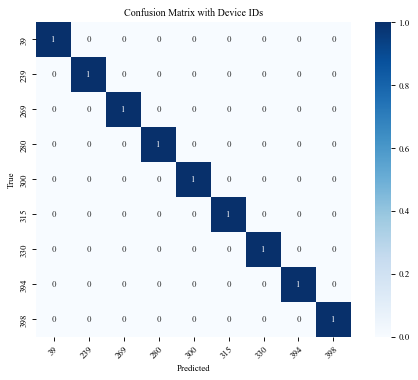

In [43]:
eval_api.evaluate_closed_set_multirx(rx_ids = RX_NODES_V2, 
    epoch_idx_enroll = 0, epoch_idx_identify = 1,
    enroll_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398],
    identify_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398],
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.55,
    fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_closed_set.eps'))

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}